
Nạp mô hình ...
✅ PGA-UNet nạp xong (2 checkpoint riêng biệt pga_256_best.pth / pga_512_best.pth — cùng kiến trúc nên số tham số/FLOPs theo shape không đổi, chỉ trọng số khác nhau).
✅ SAM-Med2D nạp xong (ViT-B, encoder_adapter=True, ảnh 256×256).

Đang đo: PGA-UNet (256×256) ...
  (đang đo thêm độ trễ CPU — mô phỏng phần cứng không GPU, có thể mất một lúc với SAM-Med2D) ...
  Tham số: 2.950M tổng / 2.950M có thể huấn luyện
  FLOPs:   7.742 GFLOPs (3.871 GMACs)
  Bộ nhớ đỉnh (GPU): 3300.8 MB
  Độ trễ (thiết bị hiện tại — cuda): 8.46 ± 0.83 ms/ảnh  (118.2 ảnh/giây)
  Độ trễ (ép chạy CPU):  83.87 ± 2.08 ms/ảnh  (11.9 ảnh/giây)
  Checkpoint trên đĩa: 11.3 MB

Đang đo: PGA-UNet (512×512) ...
  (đang đo thêm độ trễ CPU — mô phỏng phần cứng không GPU, có thể mất một lúc với SAM-Med2D) ...
  Tham số: 2.950M tổng / 2.950M có thể huấn luyện
  FLOPs:   30.968 GFLOPs (15.484 GMACs)
  Bộ nhớ đỉnh (GPU): 3429.8 MB
  Độ trễ (thiết bị hiện tại — cuda): 21.83 ± 0.23 ms/ảnh  (45.8 ảnh/giây)
  Độ trễ (é

/tmp/ipykernel_58/2063819526.py:468: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
/tmp/ipykernel_58/2063819526.py:468: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
/tmp/ipykernel_58/2063819526.py:468: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
/tmp/ipykernel_58/2063819526.py:468: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
/tmp/ipykernel_58/2063819526.py:468: UserWarning: set_ticklabels() should only b

→ Biểu đồ: /kaggle/working/results/efficiency_comparison.png


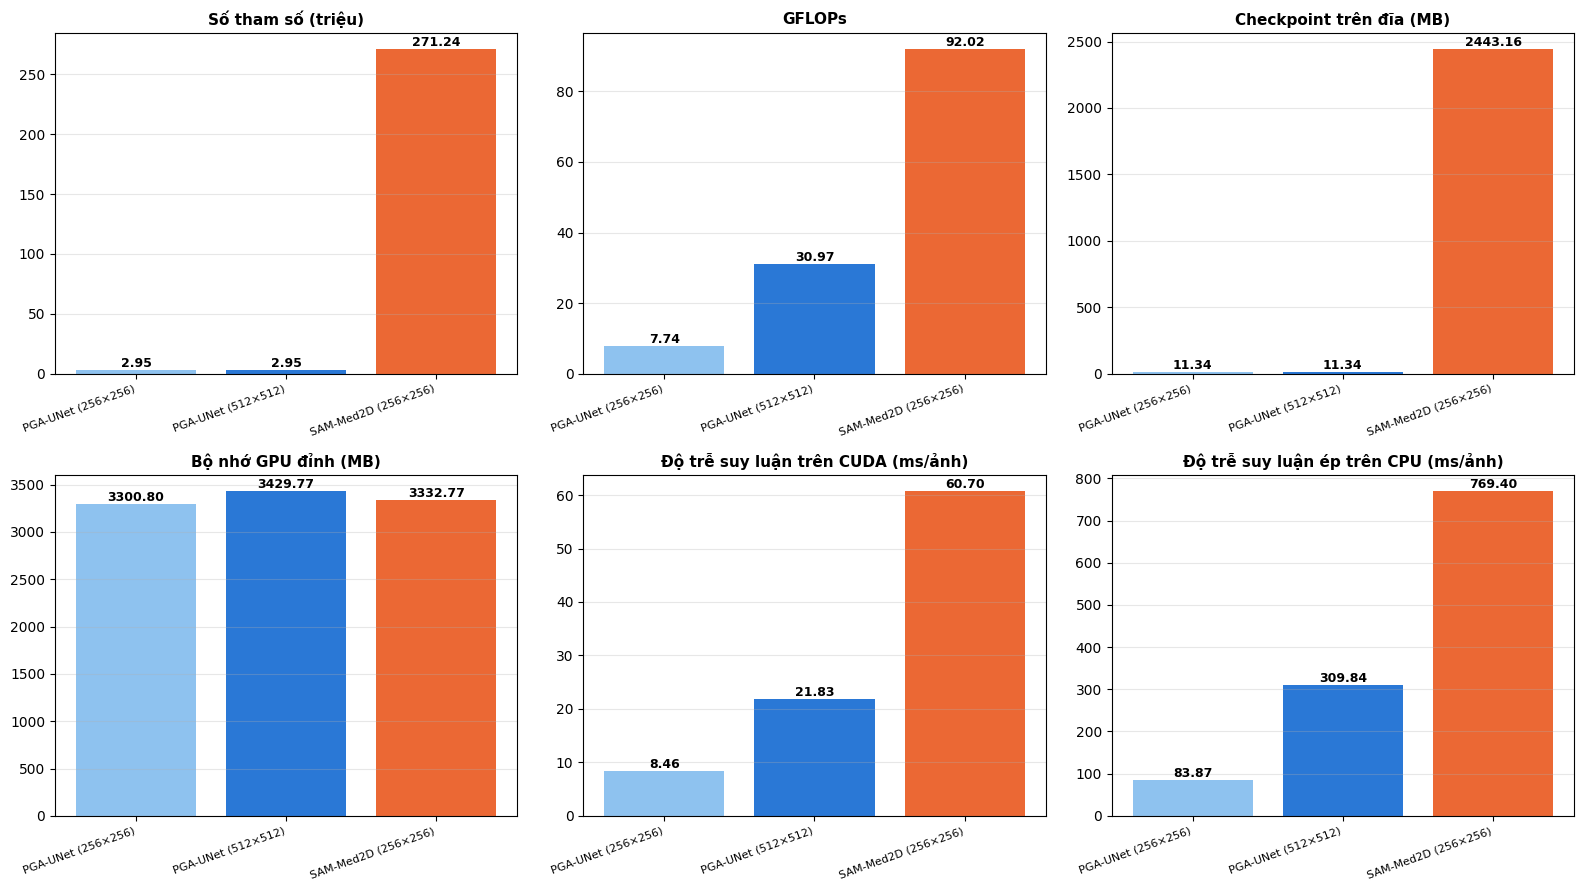

In [39]:
"""
measure_efficiency.py
══════════════════════════════════════════════════════════════════════
So sánh hiệu quả tính toán giữa PGA-UNet (256×256, 512×512) và SAM-Med2D
(256×256): số tham số (tổng + có thể huấn luyện), FLOPs/MACs, dung lượng
checkpoint trên đĩa, bộ nhớ GPU đỉnh, độ trễ suy luận trên GPU VÀ khi ép
chạy trên CPU (mô phỏng triển khai trên phần cứng không có GPU — đúng
động lực "CNN hạng nhẹ khả thi hơn Transformer nền tảng" đã nêu ở
Chương 1 nhưng khóa luận chưa từng đo thực nghiệm).

Đây là phần đo lường còn thiếu được nêu trong Chương 3/Chương 5 của khóa
luận (khóa luận chỉ đếm số tham số ~3 triệu cho PGA-UNet, chưa đo FLOPs/
latency/memory so với SAM-Med2D).

Cách chạy:
  - Kaggle / Colab (khuyến nghị, cần GPU để số liệu khớp điều kiện đã
    dùng khi huấn luyện — Kaggle T4 16GB):
        !python measure_efficiency.py
    hoặc copy toàn bộ nội dung file này vào 1 cell rồi chạy trực tiếp.
  - Máy cá nhân (CPU): vẫn chạy được, nhưng thời gian suy luận và bộ nhớ
    sẽ không phản ánh đúng điều kiện GPU đã dùng trong khóa luận — script
    sẽ tự in cảnh báo khi không có CUDA.

Yêu cầu cài đặt (script tự cài nếu thiếu):
  - fvcore (đo FLOPs, xử lý tốt attention/matmul trong ViT của SAM-Med2D,
    chính xác hơn thop cho kiến trúc Transformer)
  - gdown (tải checkpoint từ Google Drive, giống các notebook khác)

Kết quả:
  - In bảng so sánh ra màn hình, kèm tỉ lệ SAM-Med2D/PGA-UNet cho từng
    chỉ số (tiện trích thẳng vào report).
  - Lưu `results/efficiency_comparison.csv`.
  - Lưu biểu đồ cột `results/efficiency_comparison.png` (6 chỉ số: số
    tham số, GFLOPs, dung lượng checkpoint, bộ nhớ GPU đỉnh, độ trễ trên
    thiết bị hiện tại, độ trễ ép trên CPU), cùng bảng màu đã dùng xuyên
    suốt các biểu đồ khác của khóa luận (PGA-UNet = xanh dương #2a78d6,
    SAM-Med2D = cam #eb6834).
══════════════════════════════════════════════════════════════════════
"""

import os
import sys
import time
import subprocess
import argparse

# ──────────────────────────────────────────────────────────────────────
# 0. Cài thư viện còn thiếu
# ──────────────────────────────────────────────────────────────────────
def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)


for _pkg, _import_name in [("fvcore", "fvcore"), ("gdown", "gdown"),
                            ("pandas", "pandas"), ("matplotlib", "matplotlib")]:
    try:
        __import__(_import_name)
    except ImportError:
        print(f"→ Cài {_pkg} ...")
        _pip_install(_pkg)

import gdown
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from fvcore.nn import FlopCountAnalysis

# ──────────────────────────────────────────────────────────────────────
# 1. Thiết lập (giống các notebook khác trong khóa luận: BASE, clone
#    repo, tải checkpoint từ Google Drive)
# ──────────────────────────────────────────────────────────────────────
BASE = "/kaggle/working" if os.path.exists("/kaggle/working") else \
       ("/content" if os.path.exists("/content") else os.getcwd())
os.chdir(BASE)

REPO_PGA = "https://github.com/ThongLuc2k3/Prompt-Guided-XRay-Segmentation.git"
REPO_SAM = "https://github.com/OpenGVLab/SAM-Med2D/"

if not os.path.exists(f"{BASE}/pga-repo"):
    subprocess.run(["git", "clone", "-q", "-b", "TN_B_ON", REPO_PGA, f"{BASE}/pga-repo"], check=False)
if not os.path.exists(f"{BASE}/SAM-Med2D"):
    subprocess.run(["git", "clone", "-q", REPO_SAM, f"{BASE}/SAM-Med2D"], check=False)

os.makedirs(f"{BASE}/pga-repo/checkpoints", exist_ok=True)
for cid, fpath in [
    ("1Y3i4uizUfVjXtMD81FOQHseQdN-7LEJp", f"{BASE}/SAM-Med2D/best_sam.pth"),
    ("1wV7W9j-LTLaqpKI0Q7MTyF9CHdzivXhH", f"{BASE}/pga-repo/checkpoints/pga_256_best.pth"),
    ("13_51tUHcFSu85GqJTri0hDrPGcInHYBz", f"{BASE}/pga-repo/checkpoints/pga_512_best.pth"),
]:
    if not os.path.exists(fpath):
        gdown.download(f"https://drive.google.com/uc?id={cid}", fpath, quiet=False)

sys.path.insert(0, f"{BASE}/pga-repo")
sys.path.insert(0, f"{BASE}/SAM-Med2D")
for _k in list(sys.modules.keys()):
    if "segment_anything" in _k:
        del sys.modules[_k]

# ── Patch build_sam.py để cho phép image_size tùy chỉnh + encoder_adapter
#    (giống hệt patch đã dùng trong test-subcat-pga-vs-sam-r256-r512.ipynb) ──
_build_sam_path = f"{BASE}/SAM-Med2D/segment_anything/build_sam.py"
os.makedirs(os.path.dirname(_build_sam_path), exist_ok=True)
_build_sam_code = '''import torch
from functools import partial
from .modeling import ImageEncoderViT, MaskDecoder, PromptEncoder, Sam, TwoWayTransformer
from torch.nn import functional as F

def build_sam_vit_b(args):
    return _build_sam(
        encoder_embed_dim=768, encoder_depth=12,
        encoder_num_heads=12, encoder_global_attn_indexes=[2,5,8,11],
        image_size=args.image_size, checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

build_sam       = build_sam_vit_b
build_sam_vit_h = build_sam_vit_b
build_sam_vit_l = build_sam_vit_b

sam_model_registry = {
    'default': build_sam_vit_b,
    'vit_h'  : build_sam_vit_b,
    'vit_l'  : build_sam_vit_b,
    'vit_b'  : build_sam_vit_b,
}

def _build_sam(encoder_embed_dim, encoder_depth, encoder_num_heads,
               encoder_global_attn_indexes, image_size, checkpoint, encoder_adapter):
    prompt_embed_dim = 256; vit_patch_size = 16
    image_embedding_size = image_size // vit_patch_size
    sam = Sam(
        image_encoder=ImageEncoderViT(
            depth=encoder_depth, embed_dim=encoder_embed_dim, img_size=image_size,
            mlp_ratio=4, norm_layer=partial(torch.nn.LayerNorm, eps=1e-6),
            num_heads=encoder_num_heads, patch_size=vit_patch_size, qkv_bias=True,
            use_rel_pos=True, global_attn_indexes=encoder_global_attn_indexes,
            window_size=14, out_chans=prompt_embed_dim, adapter_train=encoder_adapter,
        ),
        prompt_encoder=PromptEncoder(
            embed_dim=prompt_embed_dim,
            image_embedding_size=(image_embedding_size, image_embedding_size),
            input_image_size=(image_size, image_size), mask_in_chans=16,
        ),
        mask_decoder=MaskDecoder(
            num_multimask_outputs=3,
            transformer=TwoWayTransformer(
                depth=2, embedding_dim=prompt_embed_dim, mlp_dim=2048, num_heads=8),
            transformer_dim=prompt_embed_dim, iou_head_depth=3, iou_head_hidden_dim=256,
        ),
        pixel_mean=[123.675, 116.28, 103.53],
        pixel_std=[58.395, 57.12, 57.375],
    )
    if checkpoint is not None:
        with open(checkpoint, 'rb') as f:
            sd = torch.load(f, map_location='cpu', weights_only=False)
        try:
            sam.load_state_dict(sd.get('model', sd), strict=False)
        except Exception:
            sd2 = sam.state_dict()
            new = {k: v for k, v in sd.items() if k in sd2}
            pos = new.get('image_encoder.pos_embed')
            tok = image_size // vit_patch_size
            if pos is not None and pos.shape[1] != tok:
                pos = F.interpolate(pos.permute(0,3,1,2), (tok,tok),
                                    mode='bilinear', align_corners=False)
                new['image_encoder.pos_embed'] = pos.permute(0,2,3,1)
            sd2.update(new); sam.load_state_dict(sd2)
    return sam
'''
with open(_build_sam_path, "w") as f:
    f.write(_build_sam_code)

from models.networks.prompt_unet_2D import PGA_UNet
from segment_anything import sam_model_registry

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cpu":
    print("⚠️  Không phát hiện GPU (CUDA). Số tham số/FLOPs vẫn đúng, nhưng độ trễ và "
          "bộ nhớ đo trên CPU KHÔNG phản ánh điều kiện GPU Tesla T4 đã dùng khi huấn "
          "luyện/đánh giá trong khóa luận — chỉ dùng để so sánh tương đối giữa hai mô hình.")

RESULTS_DIR = f"{BASE}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)


# ──────────────────────────────────────────────────────────────────────
# 2. Tiện ích đo lường
# ──────────────────────────────────────────────────────────────────────
def count_params(model, only_trainable=False):
    if only_trainable:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())


def count_sam_finetune_trainable(sam_model):
    """Số tham số THỰC SỰ được cập nhật khi tinh chỉnh SAM-Med2D trong khóa luận:
    chỉ các lớp Adapter trong image_encoder (backbone ViT còn lại bị đóng băng),
    cộng toàn bộ prompt_encoder và mask_decoder — đúng quy tắc freeze trong
    Source/File_Train/Finetune_SAMMed2D_test_robust.ipynb."""
    n = 0
    for name, p in sam_model.image_encoder.named_parameters():
        if "Adapter" in name:
            n += p.numel()
    n += count_params(sam_model.prompt_encoder)
    n += count_params(sam_model.mask_decoder)
    return n


def checkpoint_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2) if os.path.exists(path) else float("nan")


def measure_flops(model, inputs):
    """inputs: tuple các tensor truyền vào model(*inputs). Trả về (GFLOPs, GMACs).

    Chạy trên CPU dù model gốc ở GPU: torch.jit.trace (dùng nội bộ bởi
    fvcore) đôi khi biến một giá trị lấy từ .shape[0] thành tensor nằm
    trên CPU trong lúc trace, gây lỗi "tensors on different devices" nếu
    phần còn lại của đồ thị đang ở CUDA (gặp ở mask_decoder của SAM-Med2D).
    Đưa toàn bộ model + input về CPU khi đếm FLOPs sẽ tránh xung đột này
    hoàn toàn — số FLOPs chỉ phụ thuộc shape của tensor, không phụ thuộc
    thiết bị tính toán, nên không ảnh hưởng đến độ chính xác kết quả.
    """
    orig_device = next(model.parameters()).device
    model_cpu = model.to("cpu").eval()
    inputs_cpu = tuple(x.to("cpu") for x in inputs)
    try:
        with torch.no_grad():
            flop_counter = FlopCountAnalysis(model_cpu, inputs_cpu)
            flop_counter.unsupported_ops_warnings(False)
            flop_counter.uncalled_modules_warnings(False)
            macs = flop_counter.total()
    finally:
        model.to(orig_device)
    gmacs = macs / 1e9
    gflops = 2 * gmacs  # quy ước 1 MAC = 2 FLOPs
    return gflops, gmacs


def _timed_runs(model, inputs, device_type, n_warmup, n_runs):
    model.eval()
    with torch.no_grad():
        for _ in range(n_warmup):
            model(*inputs)
        if device_type == "cuda":
            torch.cuda.synchronize()

        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            model(*inputs)
            if device_type == "cuda":
                torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000.0)

    times = torch.tensor(times)
    mean_ms = times.mean().item()
    std_ms = times.std().item()
    fps = 1000.0 / mean_ms
    return mean_ms, std_ms, fps


def measure_latency(model, inputs, n_warmup=10, n_runs=50):
    """Độ trễ trên thiết bị hiện tại của model (GPU nếu có CUDA). Trả về (mean_ms, std_ms, fps)."""
    return _timed_runs(model, inputs, DEVICE.type, n_warmup, n_runs)


def measure_latency_cpu(model, inputs, n_warmup=5, n_runs=20):
    """Độ trễ khi buộc chạy trên CPU, kể cả khi máy có GPU — mô phỏng kịch bản triển
    khai trên phần cứng y tế không có GPU (đúng động lực 'CNN hạng nhẹ khả thi hơn
    Transformer nền tảng' đã nêu ở Chương 1, nhưng khóa luận chưa từng đo). Số lần
    lặp ít hơn measure_latency vì CPU chậm hơn nhiều, đặc biệt với ViT-B của SAM-Med2D.
    Model được trả về đúng thiết bị gốc sau khi đo."""
    orig_device = next(model.parameters()).device
    model_cpu = model.to("cpu")
    inputs_cpu = tuple(x.to("cpu") for x in inputs)
    try:
        mean_ms, std_ms, fps = _timed_runs(model_cpu, inputs_cpu, "cpu", n_warmup, n_runs)
    finally:
        model.to(orig_device)
    return mean_ms, std_ms, fps


def measure_peak_memory_mb(model, inputs):
    """Bộ nhớ GPU đỉnh (MB) trong một lượt suy luận. Trả về NaN nếu chạy trên CPU."""
    if DEVICE.type != "cuda":
        return float("nan")
    model.eval()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(DEVICE)
    with torch.no_grad():
        model(*inputs)
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 2)


class SAMWrapper(nn.Module):
    """Gộp 3 bước suy luận rời rạc của SAM-Med2D (image_encoder → prompt_encoder →
    mask_decoder) thành một lượt forward() duy nhất, để đo FLOPs/latency/memory
    theo cùng giao thức với PGA-UNet (một lệnh gọi model(*inputs) duy nhất)."""

    def __init__(self, sam_model):
        super().__init__()
        self.sam = sam_model

    def forward(self, img, box):
        emb = self.sam.image_encoder(img)
        se, de = self.sam.prompt_encoder(points=None, boxes=box, masks=None)
        low, _ = self.sam.mask_decoder(
            image_embeddings=emb,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=se,
            dense_prompt_embeddings=de,
            multimask_output=False,
        )
        return low


# ──────────────────────────────────────────────────────────────────────
# 3. Nạp mô hình
# ──────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Nạp mô hình ...")
print("=" * 70)

pga256 = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
pga256.load_state_dict(torch.load(f"{BASE}/pga-repo/checkpoints/pga_256_best.pth",
                                   map_location=DEVICE, weights_only=True))
pga256.eval()

pga512 = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
pga512.load_state_dict(torch.load(f"{BASE}/pga-repo/checkpoints/pga_512_best.pth",
                                   map_location=DEVICE, weights_only=True))
pga512.eval()
print("✅ PGA-UNet nạp xong (2 checkpoint riêng biệt pga_256_best.pth / pga_512_best.pth — "
      "cùng kiến trúc nên số tham số/FLOPs theo shape không đổi, chỉ trọng số khác nhau).")

args_sam = argparse.Namespace(image_size=256, encoder_adapter=True,
                               sam_checkpoint=f"{BASE}/SAM-Med2D/best_sam.pth")
sam_model = sam_model_registry["vit_b"](args_sam).to(DEVICE)
sam_model.eval()
sam_wrapped = SAMWrapper(sam_model).to(DEVICE)
sam_wrapped.eval()
print("✅ SAM-Med2D nạp xong (ViT-B, encoder_adapter=True, ảnh 256×256).")

# ──────────────────────────────────────────────────────────────────────
# 4. Chuẩn bị input giả lập cho từng cấu hình
# ──────────────────────────────────────────────────────────────────────
def make_pga_inputs(size):
    img = torch.randn(1, 1, size, size, device=DEVICE)
    prompt = torch.rand(1, 1, size, size, device=DEVICE)  # heatmap trong [0,1]
    return (img, prompt)


def make_sam_inputs():
    img = torch.randn(1, 3, 256, 256, device=DEVICE)
    box = torch.tensor([[[40.0, 40.0, 200.0, 200.0]]], device=DEVICE)  # [B,1,4]
    return (img, box)


configs = [
    ("PGA-UNet (256×256)", pga256, make_pga_inputs(256),
     f"{BASE}/pga-repo/checkpoints/pga_256_best.pth", count_params(pga256)),
    ("PGA-UNet (512×512)", pga512, make_pga_inputs(512),
     f"{BASE}/pga-repo/checkpoints/pga_512_best.pth", count_params(pga512)),
    ("SAM-Med2D (256×256)", sam_wrapped, make_sam_inputs(),
     f"{BASE}/SAM-Med2D/best_sam.pth", count_params(sam_model)),
]

# ──────────────────────────────────────────────────────────────────────
# 5. Chạy đo
# ──────────────────────────────────────────────────────────────────────
rows = []
for name, model, inputs, ckpt_path, n_params_total in configs:
    print(f"\nĐang đo: {name} ...")
    gflops, gmacs = measure_flops(model, inputs)
    mean_ms, std_ms, fps = measure_latency(model, inputs)
    print("  (đang đo thêm độ trễ CPU — mô phỏng phần cứng không GPU, có thể mất một lúc với SAM-Med2D) ...")
    mean_ms_cpu, std_ms_cpu, fps_cpu = measure_latency_cpu(model, inputs)
    peak_mem = measure_peak_memory_mb(model, inputs)
    ckpt_mb = checkpoint_size_mb(ckpt_path)

    if name.startswith("SAM-Med2D"):
        n_trainable = count_sam_finetune_trainable(sam_model)
    else:
        n_trainable = count_params(model, only_trainable=True)

    rows.append(dict(
        model=name,
        params_total_M=n_params_total / 1e6,
        params_trainable_M=n_trainable / 1e6,
        gflops=gflops,
        gmacs=gmacs,
        checkpoint_MB=ckpt_mb,
        peak_mem_MB=peak_mem,
        latency_ms_mean=mean_ms,
        latency_ms_std=std_ms,
        fps=fps,
        latency_ms_mean_cpu=mean_ms_cpu,
        latency_ms_std_cpu=std_ms_cpu,
        fps_cpu=fps_cpu,
    ))
    print(f"  Tham số: {n_params_total/1e6:.3f}M tổng / {n_trainable/1e6:.3f}M có thể huấn luyện")
    print(f"  FLOPs:   {gflops:.3f} GFLOPs ({gmacs:.3f} GMACs)")
    print(f"  Bộ nhớ đỉnh (GPU): {peak_mem:.1f} MB" if DEVICE.type == "cuda" else "  Bộ nhớ đỉnh: N/A (CPU)")
    print(f"  Độ trễ (thiết bị hiện tại — {DEVICE.type}): {mean_ms:.2f} ± {std_ms:.2f} ms/ảnh  ({fps:.1f} ảnh/giây)")
    print(f"  Độ trễ (ép chạy CPU):  {mean_ms_cpu:.2f} ± {std_ms_cpu:.2f} ms/ảnh  ({fps_cpu:.1f} ảnh/giây)")
    print(f"  Checkpoint trên đĩa: {ckpt_mb:.1f} MB")

df = pd.DataFrame(rows)
csv_path = f"{RESULTS_DIR}/efficiency_comparison.csv"
df.to_csv(csv_path, index=False, float_format="%.4f")

print("\n" + "=" * 70)
print("BẢNG TỔNG HỢP")
print("=" * 70)
_num_cols = ["params_total_M", "params_trainable_M", "gflops", "gmacs",
             "checkpoint_MB", "peak_mem_MB", "latency_ms_mean", "latency_ms_std", "fps",
             "latency_ms_mean_cpu", "latency_ms_std_cpu", "fps_cpu"]
print(df.to_string(index=False, formatters={c: (lambda x: f"{x:.3f}") for c in _num_cols}))
print(f"\n→ CSV: {csv_path}")

# ── Tóm tắt tỉ lệ so với PGA-UNet cùng độ phân giải (256), tiện trích vào report ──
try:
    r_pga = df[df["model"] == "PGA-UNet (256×256)"].iloc[0]
    r_sam = df[df["model"] == "SAM-Med2D (256×256)"].iloc[0]
    print("\n" + "-" * 70)
    print("So sánh SAM-Med2D / PGA-UNet, cùng độ phân giải 256×256:")
    print(f"  Số tham số:        {r_sam['params_total_M']/r_pga['params_total_M']:.1f}× "
          f"({r_sam['params_total_M']:.2f}M so với {r_pga['params_total_M']:.2f}M)")
    print(f"  GFLOPs:            {r_sam['gflops']/r_pga['gflops']:.1f}×")
    print(f"  Checkpoint (MB):   {r_sam['checkpoint_MB']/r_pga['checkpoint_MB']:.1f}×")
    if DEVICE.type == "cuda":
        print(f"  Độ trễ GPU:        {r_sam['latency_ms_mean']/r_pga['latency_ms_mean']:.1f}×")
    print(f"  Độ trễ CPU:        {r_sam['latency_ms_mean_cpu']/r_pga['latency_ms_mean_cpu']:.1f}×")
    print("-" * 70)
except (IndexError, KeyError, ZeroDivisionError):
    pass

# ──────────────────────────────────────────────────────────────────────
# 6. Biểu đồ so sánh (cùng bảng màu đã dùng trong các biểu đồ khác của
#    khóa luận: PGA-UNet = xanh dương #2a78d6, SAM-Med2D = cam #eb6834)
# ──────────────────────────────────────────────────────────────────────
COLORS = {"PGA-UNet (256×256)": "#8ec2ef",
          "PGA-UNet (512×512)": "#2a78d6",
          "SAM-Med2D (256×256)": "#eb6834"}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
metrics = [
    ("params_total_M", "Số tham số (triệu)", axes[0]),
    ("gflops", "GFLOPs", axes[1]),
    ("checkpoint_MB", "Checkpoint trên đĩa (MB)", axes[2]),
    ("peak_mem_MB", "Bộ nhớ GPU đỉnh (MB)", axes[3]),
    ("latency_ms_mean", f"Độ trễ suy luận trên {DEVICE.type.upper()} (ms/ảnh)", axes[4]),
    ("latency_ms_mean_cpu", "Độ trễ suy luận ép trên CPU (ms/ảnh)", axes[5]),
]
for col, label, ax in metrics:
    vals = df[col].tolist()
    names = df["model"].tolist()
    bars = ax.bar(names, vals, color=[COLORS.get(n, "#888888") for n in names])
    for b, v in zip(bars, vals):
        txt = "N/A" if (isinstance(v, float) and v != v) else f"{v:.2f}"
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), txt,
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
png_path = f"{RESULTS_DIR}/efficiency_comparison.png"
plt.savefig(png_path, dpi=150, bbox_inches="tight")
print(f"→ Biểu đồ: {png_path}")

if DEVICE.type != "cuda":
    print("\n⚠️  Nhắc lại: chạy script này trên Kaggle/Colab có GPU trước khi đưa số liệu "
          "bộ nhớ/độ trễ vào báo cáo, để khớp điều kiện phần cứng (Tesla T4) đã dùng "
          "xuyên suốt khóa luận.")
